In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 80s 0us/step 


In [4]:
x_train=x_train/255.0
x_test=x_test/255.0

In [3]:
#datagen=ImageDataGenerator()

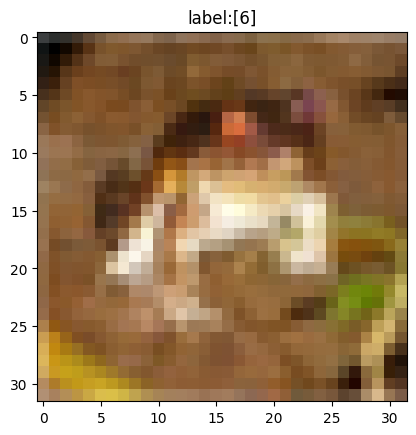

In [5]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.title(f'label:{y_train[0]}')
plt.show()

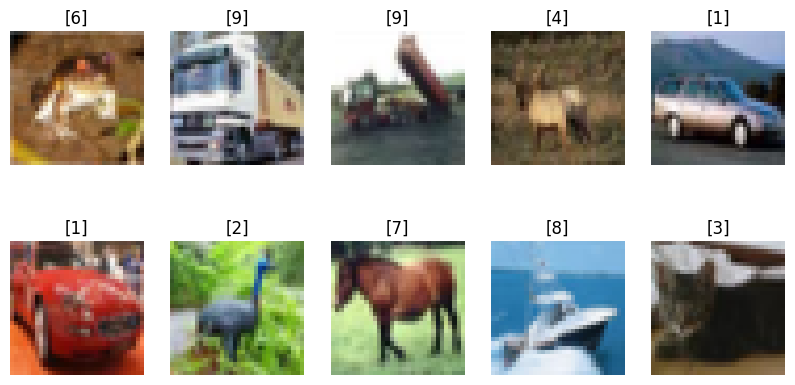

In [9]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [10]:
x_train.shape

(50000, 32, 32, 3)

In [11]:
model=Sequential()
#conv block 1
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))
#conv block2
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
#flatten
model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
model.fit(x_train,y_train,epochs=5,validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4394 - loss: 1.5559 - val_accuracy: 0.5396 - val_loss: 1.3145
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5633 - loss: 1.2300 - val_accuracy: 0.5900 - val_loss: 1.1716
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6127 - loss: 1.0977 - val_accuracy: 0.6302 - val_loss: 1.0561
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6476 - loss: 1.0084 - val_accuracy: 0.6257 - val_loss: 1.0710
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6672 - loss: 0.9539 - val_accuracy: 0.6429 - val_loss: 1.0372


In [14]:
loss,accuracy=model.evaluate(x_test,y_test)
print('test_accuracy:',accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6456 - loss: 1.0317
test_accuracy: 0.6456000208854675


In [15]:
import numpy as np
pred=model.predict(x_test[:1])
print('predicted:',np.argmax(pred))
print('actual:',y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
predicted: 3
actual: [3]
